# Task 1: End-to-End Data Cleaning Project
**Organization**: WeIntern Pvt Ltd  
**Track**: Data Science & Machine Learning Engineering  
**Module**: Advanced Data Preparation & Quality Assurance  
**Author**: Bineeta Yadav (Data Science Intern, WeIntern Pvt Ltd)  
**Repository**: [Task1_Data_Cleaning_Project](https://github.com/bineetayadav/Task1_Data_Cleaning_Project)  
**Dataset**: Enterprise Customer Churn & Demographics (`customer_churn_raw.csv`)  
**Objective**: Ingest a messy, raw real-world dataset and transform it into a pristine, analysis-ready and ML-ready format using Python's Pandas, NumPy, Matplotlib, and Seaborn.

---

### Project Lifecycle & Implementation Workflow
This notebook walks through the systematic 10-step data cleaning lifecycle:
1. **Initial Exploration & Profiling**: Ingest raw dataset; audit shape, schema, `.info()`, `.describe()`, and initial samples.
2. **Missing Data Diagnostics**: Visualize missingness patterns using Seaborn heatmaps and column-wise percentage bars.
3. **Missing Value Strategy & Imputation**: Formulate and apply column-specific strategies (drop unidentifiable records, median imputation for skewed numericals, mode/unknown imputation for categoricals, tenure-reconciled totals).
4. **Duplicate Row Auditing & Deduplication**: Detect exact duplicates and primary key conflicts using `.duplicated()`, remove with `.drop_duplicates()`.
5. **Column Standardization & Type Corrections**: Normalize column names to `snake_case`; correct string currencies, blanks, and mixed date strings into proper numeric and `datetime64[ns]` formats.
6. **Outlier Detection & Statistical Handling**: Identify anomalies using Boxplots, IQR method, and Z-score evaluation ($|Z| > 3$); apply Winsorization/clipping.
7. **Categorical Encoding & Feature Scaling**: Implement One-Hot Encoding for nominal variables, Ordinal Encoding for ranked tiers, and Min-Max feature normalization.
8. **Post-Cleaning Validation**: Validate integrity using descriptive statistics, zero-null assertions, and distribution plots.
9. **Export Cleaned Assets**: Export cleaned analysis-ready CSV and ML-encoded CSV.
10. **Data Quality Evaluation**: Before-and-after comparison table of comprehensive data quality metrics.


## Step 0: Environment Setup & Library Imports
We initialize standard data manipulation and visualization libraries with configured styling parameters.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure presentation styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#CBD5E1'
plt.rcParams['figure.facecolor'] = '#FFFFFF'
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

print("Environment configured successfully. Ready for data cleaning pipeline.")

Environment configured successfully. Ready for data cleaning pipeline.


## Step 1: Load Dataset & Perform Initial Exploration
We load the raw, messy dataset from `../data/raw/customer_churn_raw.csv` and inspect its dimensions, data types, missing values count, and top rows.


In [2]:
# Load raw dataset
raw_df = pd.read_csv('../data/raw/customer_churn_raw.csv')

print(f"Raw Dataset Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
print(f"Total Cells: {raw_df.size:,}")
print(f"Total Missing Cells: {raw_df.isnull().sum().sum():,} ({raw_df.isnull().sum().sum() / raw_df.size:.2%})")
print(f"Total Exact Duplicate Rows: {raw_df.duplicated().sum()}")

Raw Dataset Shape: 1550 rows, 16 columns
Total Cells: 24,800
Total Missing Cells: 1,522 (6.14%)
Total Exact Duplicate Rows: 35


In [3]:
# Display schema information and datatypes
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1550 entries, 0 to 1549
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0    Customer_ID              1524 non-null   object 
 1   Full_Name                 1550 non-null   object 
 2   Age                       1449 non-null   float64
 3   Gender                    1467 non-null   object 
 4   Annual Income ($)         1430 non-null   object 
 5   Tenure Months             1441 non-null   float64
 6   Contract-Type             1480 non-null   object 
 7   Payment_Method            1459 non-null   object 
 8   Monthly Charges ($)       1458 non-null   float64
 9   Total Charges             1488 non-null   object 
 10  Internet Service          1390 non-null   object 
 11  Tech Support              1329 non-null   object 
 12  Satisfaction Score (1-5)  1415 non-null   float64
 13  Join Date                 1464 non-null   object 
 14  City    

In [4]:
# Preview first 5 records of raw dataset
raw_df.head()

,Customer_ID,Full_Name,Age,Gender,Annual Income ($),Tenure Months,Contract-Type,Payment_Method,Monthly Charges ($),Total Charges,Internet Service,Tech Support,Satisfaction Score (1-5),Join Date,City,Churn
0,CUST-2237,Nancy Gonzalez,45.0,female,"$164,200",15.0,M2M,Electronic Check,22.41,338.48,Fiber,no internet,4.0,2022-01-25,Phoenix,1
1,CUST-2442,Sarah Hernandez,29.0,female,128958,59.0,NaN,Credit Card,114.48,6751.46,dsl,FALSE,4.0,09-23-2021,Hyderabad,yes
2,CUST-1352,Mark Jones,32.0,M,"$70,554",NaN,Two Year,bank transfer,26.83,$453.49,FIBER,NaN,2.0,19/06/2024,New York,no
3,CUST-1353,Vikram Jones,48.0,MALE,"$68,248.00",21.0,2 Year,mailed check,60.42,1265.21,Fiber,0,4.0,08-10-2023,Berlin,NaN
4,CUST-1579,Barbara Patel,59.0,other,128777,62.0,Month-to-Month,Check,81.77,5075.97,FIBER,no,3.0,2020-01-03,Sydney,no


In [5]:
# Preliminary summary statistics for numerical attributes
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1449.0,42.360248,23.436996,-10.0,31.00,41.00,51.0000,225.0
Tenure Months,1441.0,36.582859,21.265057,-6.0,18.00,37.00,55.0000,72.0
Monthly Charges ($),1458.0,95.481365,162.826536,0.0,43.51,69.34,96.8725,1250.0
Satisfaction Score (1-5),1415.0,2.967491,1.570256,-1.0,2.00,3.00,4.0000,10.0


## Step 2: Visualize Missing Data
To diagnose whether missingness occurs at random or across specific features, we construct a Missing Data Heatmap using Seaborn alongside a column-wise percentage bar chart.


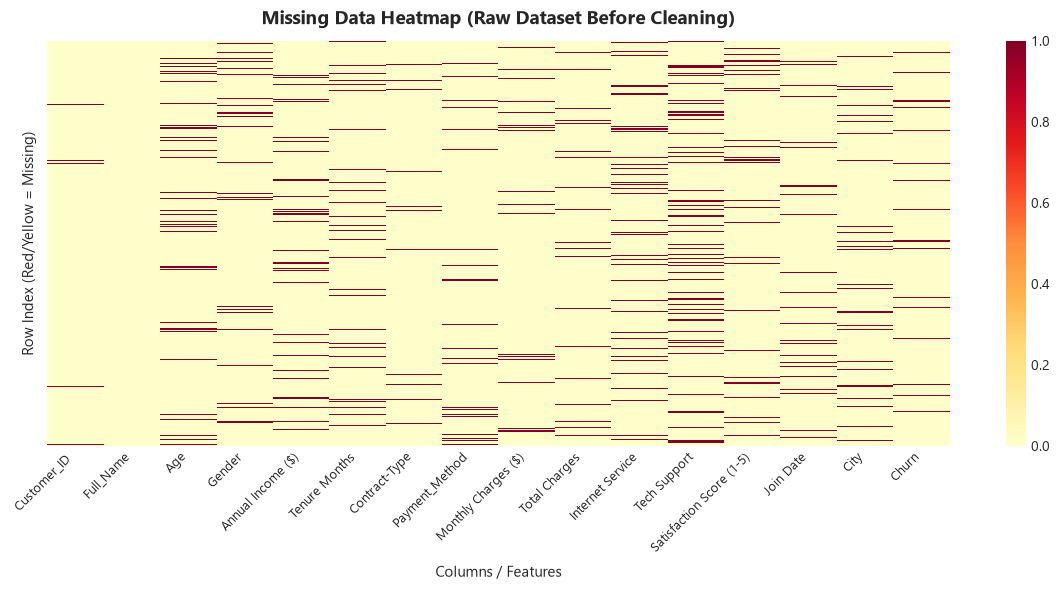

In [6]:
# 2.1 Missing Data Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(raw_df.isnull(), cbar=True, cmap="YlOrRd", yticklabels=False)
plt.title("Missing Data Heatmap (Raw Dataset Before Cleaning)", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Columns / Features", fontsize=11, labelpad=8)
plt.ylabel("Row Index (Red/Yellow = Missing)", fontsize=11, labelpad=8)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

Columns with Missing Values:


,Missing_Count,Missing_Percentage
Tech Support,221,14.258065
Internet Service,160,10.322581
Satisfaction Score (1-5),135,8.709677
Annual Income ($),120,7.741935
Tenure Months,109,7.032258
Age,101,6.516129
City,98,6.322581
Monthly Charges ($),92,5.935484
Payment_Method,91,5.870968
Join Date,86,5.548387


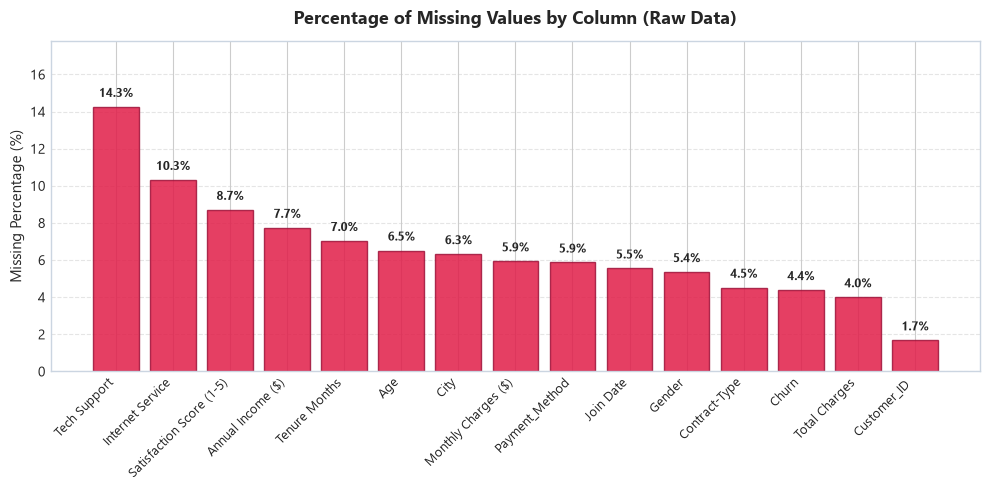

In [7]:
# 2.2 Missing Values Breakdown by Column
null_counts = raw_df.isnull().sum()
null_percent = (null_counts / len(raw_df)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': null_counts,
    'Missing_Percentage': null_percent
}).loc[lambda df: df['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)

print("Columns with Missing Values:")
display(missing_summary)

plt.figure(figsize=(10, 5))
bars = plt.bar(missing_summary.index, missing_summary['Missing_Percentage'], color='#E11D48', edgecolor='#9F1239', alpha=0.85)
plt.title("Percentage of Missing Values by Column (Raw Data)", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Missing Percentage (%)", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylim(0, missing_summary['Missing_Percentage'].max() * 1.25)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.4, f"{h:.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Step 4: Detect & Remove Duplicate Rows
We identify and eliminate both:
1. **Exact duplicate rows** where all columns are identical due to repeated batch ingestion.
2. **Primary Key duplicates** where the same `Customer_ID` was logged multiple times with slight variations.


In [8]:
df = raw_df.copy()

# Audit exact duplicates
exact_dups = df.duplicated()
print(f"Exact duplicate rows detected: {exact_dups.sum()}")

# Drop exact duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after dropping exact duplicates: {df.shape}")

Exact duplicate rows detected: 35
Dataset shape after dropping exact duplicates: (1515, 16)


## Step 5: Standardize Column Names to `snake_case`
Raw column names frequently contain leading/trailing whitespaces, mixed casing, parentheses, dollar signs, and hyphens (e.g. `' Customer_ID '`, `'Annual Income ($)'`, `'Contract-Type'`). We normalize all headers to clean `snake_case`.


In [9]:
def clean_column_name(col: str) -> str:
    col = col.strip().lower()
    col = re.sub(r'[\$\(\)]', '', col)
    col = re.sub(r'[\s\-]+', '_', col)
    col = re.sub(r'_+', '_', col)
    col = col.strip('_')
    # Specific normalization
    mapping = {
        "customer_id": "customer_id",
        "full_name": "full_name",
        "age": "age",
        "gender": "gender",
        "annual_income": "annual_income",
        "tenure_months": "tenure_months",
        "contract_type": "contract_type",
        "payment_method": "payment_method",
        "monthly_charges": "monthly_charges",
        "total_charges": "total_charges",
        "internet_service": "internet_service",
        "tech_support": "tech_support",
        "satisfaction_score_1_5": "satisfaction_score",
        "satisfaction_score": "satisfaction_score",
        "join_date": "join_date",
        "city": "city",
        "churn": "churn"
    }
    return mapping.get(col, col)

df.columns = [clean_column_name(c) for c in df.columns]
print("Standardized Column Names:")
print(list(df.columns))

Standardized Column Names:
['customer_id', 'full_name', 'age', 'gender', 'annual_income', 'tenure_months', 'contract_type', 'payment_method', 'monthly_charges', 'total_charges', 'internet_service', 'tech_support', 'satisfaction_score', 'join_date', 'city', 'churn']


In [10]:
# Primary key validation on 'customer_id'
# 1. Drop rows where customer_id is null (cannot identify customer)
null_ids = df['customer_id'].isnull().sum()
print(f"Rows with null customer_id: {null_ids} -> Dropping")
df = df.dropna(subset=['customer_id']).reset_index(drop=True)

# 2. Drop duplicate customer_id rows (keep first occurrence)
pk_dups = df.duplicated(subset=['customer_id'], keep='first').sum()
print(f"Duplicate customer_id entries: {pk_dups} -> Removing secondary occurrences")
df = df.drop_duplicates(subset=['customer_id'], keep='first').reset_index(drop=True)

# 3. Drop records with missing target variable 'churn' (prevent synthetic bias in analysis)
null_targets = df['churn'].isnull().sum()
print(f"Records with missing target 'churn': {null_targets} -> Dropping")
df = df.dropna(subset=['churn']).reset_index(drop=True)

print(f"Shape after identifier and target validation: {df.shape}")

Rows with null customer_id: 26 -> Dropping
Duplicate customer_id entries: 14 -> Removing secondary occurrences
Records with missing target 'churn': 62 -> Dropping
Shape after identifier and target validation: (1413, 16)


## Step 3 & 5 (Continued): Column-Specific Missing Value Imputation & Type Corrections
We apply domain-appropriate strategies for each attribute:
- **`full_name`**: Clean extra spaces and standardize to Title Case.
- **`annual_income`**: Strip currency formatting (`$`, `,`), treat negative numbers as entry errors, impute missing values with the **median**, and convert to `float64`.
- **`age`**: Treat negative entries as entry typos, remove impossible human ages (>120), impute missing with **median**, and cast to integer `int64`.
- **`tenure_months`**: Replace negative tenures with 0, impute missing with **median**, and cast to integer `int64`.
- **`monthly_charges`**: Replace zeros and unphysical negative values, impute missing with **median**, and cast to `float64`.
- **`total_charges`**: Convert empty space strings (`' '`) to NaN, strip formatting, and dynamically recalculate missing total charges as $\text{tenure\_months} \times \text{monthly\_charges}$.
- **`satisfaction_score`**: Filter invalid scale entries (<1 or >5), impute missing with median score (3), and cast to `int64`.
- **`join_date`**: Parse mixed date formats (`YYYY-MM-DD`, `DD/MM/YYYY`, `MM-DD-YYYY`) to standard `datetime64[ns]`, imputing missing dates using tenure.
- **Categoricals** (`gender`, `contract_type`, `payment_method`, `internet_service`, `tech_support`, `city`, `churn`): Normalize spelling variations and impute missing values with mode or dedicated `'Unknown'` category.


In [11]:
# 1. full_name
df['full_name'] = df['full_name'].astype(str).apply(lambda x: re.sub(r'\s+', ' ', x.strip()).title())

# 2. annual_income ($)
def parse_currency(val):
    if pd.isnull(val):
        return np.nan
    s = str(val).strip()
    is_neg = '-' in s
    s = re.sub(r'[\$,\s\-]', '', s)
    try:
        num = float(s)
        return -num if is_neg else num
    except ValueError:
        return np.nan

df['annual_income'] = df['annual_income'].apply(parse_currency)
df.loc[df['annual_income'] < 0, 'annual_income'] = np.nan
median_income = df['annual_income'].median()
df['annual_income'] = df['annual_income'].fillna(median_income)
print(f"Annual Income: parsed currency strings, imputed missing with median (${median_income:,.2f})")

Annual Income: parsed currency strings, imputed missing with median ($87,396.00)


In [12]:
# 3. age
df.loc[df['age'] < 0, 'age'] = np.nan
df.loc[df['age'] > 120, 'age'] = np.nan
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age).round().astype(int)
print(f"Age: imputed missing with median ({median_age:.0f} yrs) and cast to int64")

# 4. tenure_months
df.loc[df['tenure_months'] < 0, 'tenure_months'] = 0
median_tenure = df['tenure_months'].median()
df['tenure_months'] = df['tenure_months'].fillna(median_tenure).round().astype(int)
print(f"Tenure Months: imputed missing with median ({median_tenure:.0f} mos) and cast to int64")

# 5. monthly_charges
df.loc[df['monthly_charges'] <= 0, 'monthly_charges'] = np.nan
median_mc = df['monthly_charges'].median()
df['monthly_charges'] = df['monthly_charges'].fillna(median_mc).astype(float)
print(f"Monthly Charges: imputed missing with median (${median_mc:.2f}) and cast to float64")

Age: imputed missing with median (41 yrs) and cast to int64
Tenure Months: imputed missing with median (37 mos) and cast to int64
Monthly Charges: imputed missing with median ($70.97) and cast to float64


In [13]:
# 6. total_charges
def parse_total_charges(val):
    if pd.isnull(val):
        return np.nan
    s = str(val).strip()
    if s == "" or s.lower() in ["nan", "null", "none", " "]:
        return np.nan
    s = re.sub(r'[\$,\s]', '', s)
    try:
        return float(s)
    except ValueError:
        return np.nan

df['total_charges'] = df['total_charges'].apply(parse_total_charges)
# Impute missing total_charges via domain formula: tenure_months * monthly_charges
missing_tc = df['total_charges'].isnull().sum()
df['total_charges'] = df['total_charges'].fillna(df['tenure_months'] * df['monthly_charges'])
print(f"Total Charges: reconciled {missing_tc} missing values using tenure_months * monthly_charges")

# 7. satisfaction_score
df.loc[~df['satisfaction_score'].isin([1, 2, 3, 4, 5]), 'satisfaction_score'] = np.nan
median_score = df['satisfaction_score'].median()
df['satisfaction_score'] = df['satisfaction_score'].fillna(median_score).round().astype(int)
print(f"Satisfaction Score: imputed missing with median ({median_score:.0f}) and cast to int64")

Total Charges: reconciled 174 missing values using tenure_months * monthly_charges
Satisfaction Score: imputed missing with median (3) and cast to int64


In [14]:
# 8. join_date
df['join_date'] = pd.to_datetime(df['join_date'], format='mixed', errors='coerce')
ref_date = pd.Timestamp("2024-12-31")
missing_dates = df['join_date'].isnull().sum()
if missing_dates > 0:
    imputed_dates = ref_date - pd.to_timedelta(df.loc[df['join_date'].isnull(), 'tenure_months'] * 30.4375, unit='D')
    df.loc[df['join_date'].isnull(), 'join_date'] = imputed_dates
print(f"Join Date: converted heterogeneous date strings to datetime64[ns] ({missing_dates} imputed from tenure)")

Join Date: converted heterogeneous date strings to datetime64[ns] (120 imputed from tenure)


In [15]:
# 9. Categorical standardization
# Gender
def clean_gender(val):
    if pd.isnull(val):
        return "Unspecified"
    s = str(val).strip().lower()
    if s in ["male", "m"]:
        return "Male"
    elif s in ["female", "f"]:
        return "Female"
    else:
        return "Other"
df['gender'] = df['gender'].apply(clean_gender)

# Contract Type
def clean_contract(val):
    if pd.isnull(val):
        return "Month-to-Month"
    s = str(val).strip().lower()
    if "two" in s or "2" in s:
        return "Two Year"
    elif "one" in s or "1" in s:
        return "One Year"
    else:
        return "Month-to-Month"
df['contract_type'] = df['contract_type'].apply(clean_contract)

# Payment Method
def clean_payment(val):
    if pd.isnull(val):
        return "Unknown"
    s = str(val).strip().lower()
    if "electronic" in s or "e-check" in s:
        return "Electronic Check"
    elif "mailed" in s or "check" in s:
        return "Mailed Check"
    elif "bank" in s:
        return "Bank Transfer"
    elif "credit" in s:
        return "Credit Card"
    else:
        return "Unknown"
df['payment_method'] = df['payment_method'].apply(clean_payment)

# Internet Service & Tech Support
df['internet_service'] = df['internet_service'].apply(lambda s: "Fiber Optic" if "fiber" in str(s).lower() else ("DSL" if "dsl" in str(s).lower() else "No"))
df['tech_support'] = df['tech_support'].apply(lambda s: "Yes" if str(s).strip().lower() in ["yes", "y", "true", "1"] else ("No internet service" if "no internet" in str(s).lower() else "No"))

# City & Churn
df['city'] = df['city'].astype(str).apply(lambda x: "Unknown" if x.strip().lower() in ["nan", "null", "none", ""] else x.strip().title())
df['churn'] = df['churn'].apply(lambda s: "Yes" if str(s).strip().lower() in ["yes", "y", "true", "1"] else "No")

print("Categorical standardization complete.")
print(df[['gender', 'contract_type', 'payment_method', 'internet_service', 'tech_support', 'churn']].nunique())

Categorical standardization complete.
gender              4
contract_type       3
payment_method      5
internet_service    3
tech_support        3
churn               2
dtype: int64


## Step 6: Detect & Handle Outliers Using IQR and Z-Score Methods
We evaluate numerical features (`age`, `annual_income`, `tenure_months`, `monthly_charges`, `total_charges`) for anomalies.
We employ both:
1. **IQR Method**:
   $$\text{IQR} = Q_3 - Q_1$$
   $$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$
2. **Z-Score Method**:
   $$Z = \frac{x - \mu}{\sigma}, \quad |Z| > 3$$

We then apply **Winsorization / IQR Capping** to constrain severe financial outliers without dropping valuable customer records.


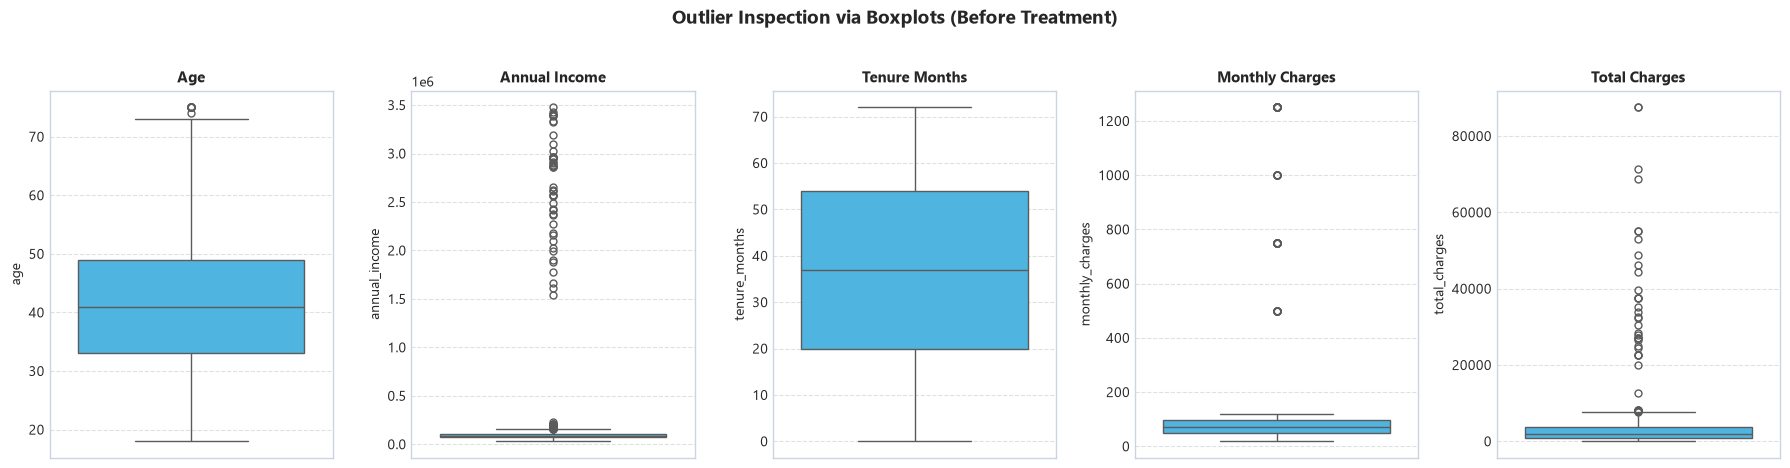

In [16]:
num_cols = ["age", "annual_income", "tenure_months", "monthly_charges", "total_charges"]

# Boxplots BEFORE outlier treatment
fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#38BDF8", flierprops={"marker": "o", "color": "#E11D48", "markersize": 5})
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight="bold")
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)
plt.suptitle("Outlier Inspection via Boxplots (Before Treatment)", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

In [17]:
# Compute IQR and Z-Score Statistics
outlier_metrics = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    iqr_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    mean_val = df[col].mean()
    std_val = df[col].std()
    z_scores = np.abs((df[col] - mean_val) / std_val)
    z_outliers = (z_scores > 3.0).sum()

    outlier_metrics.append({
        "Feature": col,
        "Mean": mean_val,
        "Std Dev": std_val,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "IQR Lower Bound": lower_bound,
        "IQR Upper Bound": upper_bound,
        "IQR Outliers (Count)": iqr_outliers,
        "Z-Score (|Z|>3) Outliers": z_outliers
    })

outlier_table = pd.DataFrame(outlier_metrics)
display(outlier_table)

,Feature,Mean,Std Dev,Q1,Q3,IQR,IQR Lower Bound,IQR Upper Bound,IQR Outliers (Count),Z-Score (|Z|>3) Outliers
0,age,41.215145,12.813176,33.00,49.00,16.00,9.000,73.000,10,0
1,annual_income,173122.382873,466917.954949,70052.00,106055.00,36003.00,16047.500,160059.500,82,45
2,tenure_months,36.854211,20.422727,20.00,54.00,34.00,-31.000,105.000,0,0
3,monthly_charges,94.301607,153.695982,47.66,96.03,48.37,-24.895,168.585,41,33
4,total_charges,3241.039349,6375.541933,970.28,3703.32,2733.04,-3129.280,7802.880,39,30


Capped 82 values in 'annual_income' to range [16047.50, 160059.50].
Capped 41 values in 'monthly_charges' to range [0.00, 168.59].


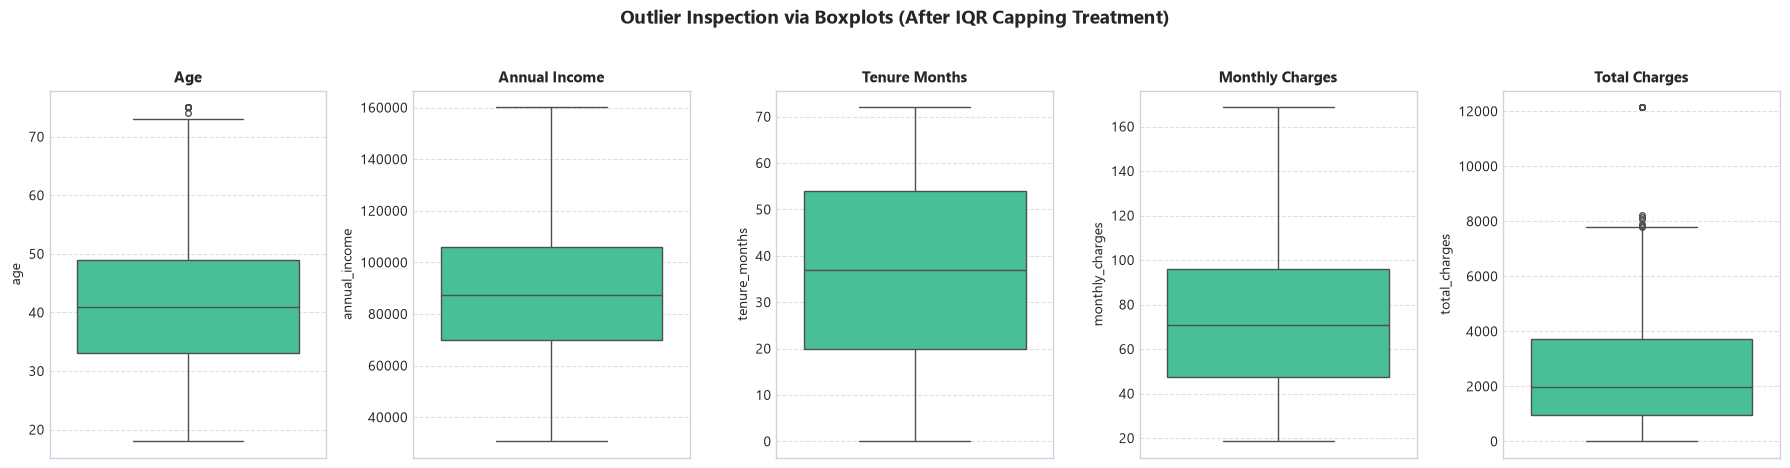

In [18]:
# Apply Winsorization / IQR Capping to financial variables
for col in ["annual_income", "monthly_charges"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = max(0.0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr
    initial_clipped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"Capped {initial_clipped} values in '{col}' to range [{lower:.2f}, {upper:.2f}].")

# Total charges re-capping
df['total_charges'] = df['total_charges'].clip(lower=0.0, upper=df['tenure_months'].max() * df['monthly_charges'].max())

# Boxplots AFTER outlier treatment
fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#34D399", flierprops={"marker": "o", "color": "#059669", "markersize": 4})
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight="bold")
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)
plt.suptitle("Outlier Inspection via Boxplots (After IQR Capping Treatment)", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Step 7: Normalize or Encode Categorical Variables
To prepare the dataset for predictive machine learning models, we implement:
1. **Ordinal Encoding**: For ordered factors like `contract_type` (Month-to-Month: 0, One Year: 1, Two Year: 2).
2. **Binary Encoding**: For binary target `churn` (No: 0, Yes: 1).
3. **One-Hot Encoding**: For nominal categories (`gender`, `internet_service`, `tech_support`, `payment_method`) using `pd.get_dummies(..., drop_first=True)`.
4. **Min-Max Feature Scaling**: Transforming numerical features into the standard $[0, 1]$ interval.


In [19]:
df_encoded = df.copy()

# 1. Ordinal Encoding
contract_map = {"Month-to-Month": 0, "One Year": 1, "Two Year": 2}
df_encoded['contract_type_encoded'] = df_encoded['contract_type'].map(contract_map)

# 2. Binary Encoding
churn_map = {"No": 0, "Yes": 1}
df_encoded['churn_encoded'] = df_encoded['churn'].map(churn_map)

# 3. One-Hot Encoding
nominal_cols = ["gender", "internet_service", "tech_support", "payment_method"]
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True, dtype=int)

# 4. Min-Max Normalization
for col in ["annual_income", "monthly_charges", "total_charges"]:
    c_min = df_encoded[col].min()
    c_max = df_encoded[col].max()
    df_encoded[f"{col}_normalized"] = (df_encoded[col] - c_min) / (c_max - c_min)

print("ML-Ready Encoded Dataset Dimensions:", df_encoded.shape)
df_encoded.head()

ML-Ready Encoded Dataset Dimensions: (1413, 28)


,customer_id,full_name,age,annual_income,tenure_months,contract_type,monthly_charges,total_charges,satisfaction_score,join_date,city,churn,contract_type_encoded,churn_encoded,gender_Male,gender_Other,gender_Unspecified,internet_service_Fiber Optic,internet_service_No,tech_support_No internet service,tech_support_Yes,payment_method_Credit Card,payment_method_Electronic Check,payment_method_Mailed Check,payment_method_Unknown,annual_income_normalized,monthly_charges_normalized,total_charges_normalized
0,CUST-2237,Nancy Gonzalez,45,160059.5,15,Two Year,22.41,338.48,4,2022-01-25,Phoenix,Yes,2,1,0,0,0,1,0,1,0,0,1,0,0,1.000000,0.025727,0.027886
1,CUST-2442,Sarah Hernandez,29,128958.0,59,Month-to-Month,114.48,6751.46,4,2021-09-23,Hyderabad,Yes,0,1,0,0,0,0,0,0,0,1,0,0,0,0.759664,0.639384,0.556220
2,CUST-1352,Mark Jones,32,70554.0,37,Two Year,26.83,453.49,2,2024-06-19,New York,No,2,0,1,0,0,1,0,0,0,0,0,0,0,0.308349,0.055187,0.037361
3,CUST-1579,Barbara Patel,59,128777.0,62,Month-to-Month,81.77,5075.97,3,2020-01-03,Sydney,No,0,0,0,1,0,1,0,0,0,0,0,1,0,0.758265,0.421368,0.418184
4,CUST-1355,Richard Hernandez,41,96286.0,23,Two Year,105.93,2431.29,4,2023-02-26,Toronto,No,2,0,1,0,0,1,0,0,0,0,0,0,0,0.507192,0.582397,0.200302


## Step 8: Validate the Cleaned Dataset with Summary Statistics
We run comprehensive integrity assertions and inspect final distributions to confirm the dataset is clean and analysis-ready.


In [20]:
# Summary statistics of clean dataset
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
age,1413.0,41.215145,18.0,33.0,41.0,49.0,75.0,12.813176
annual_income,1413.0,91268.871196,30651.0,70052.0,87396.0,106055.0,160059.5,29965.331797
tenure_months,1413.0,36.854211,0.0,20.0,37.0,54.0,72.0,20.422727
monthly_charges,1413.0,72.478567,18.55,47.66,70.97,96.03,168.585,32.316144
total_charges,1413.0,2633.298365,0.0,970.28,1985.3,3703.32,12138.12,2337.837195
satisfaction_score,1413.0,2.95046,1.0,2.0,3.0,4.0,5.0,1.331821
join_date,1413,2022-07-15 06:06:06.878980864,2018-12-31 12:00:00,2021-04-01 00:00:00,2022-08-10 00:00:00,2023-11-17 00:00:00,2024-12-28 00:00:00,NaN


In [21]:
# Automated Data Quality Assertions
assert df.isnull().sum().sum() == 0, "Data validation failed: Null values remain!"
assert df.duplicated().sum() == 0, "Data validation failed: Duplicate rows remain!"
assert df.duplicated(subset=['customer_id']).sum() == 0, "Data validation failed: Duplicate IDs remain!"
assert (df['age'] < 18).sum() == 0, "Data validation failed: Minor age detected!"
assert (df['annual_income'] < 0).sum() == 0, "Data validation failed: Negative income detected!"
assert (df['monthly_charges'] <= 0).sum() == 0, "Data validation failed: Non-positive charge detected!"

print(" ALL 6 DATA INTEGRITY ASSERTIONS PASSED SUCCESSFULLY!")
print(f"Total Clean Records: {len(df):,}")
print(f"Null Values Remaining: {df.isnull().sum().sum()} (0.00%)")
print(f"Primary Key Uniqueness: {df['customer_id'].nunique():,} / {len(df):,} (100.0%)")

 ALL 6 DATA INTEGRITY ASSERTIONS PASSED SUCCESSFULLY!
Total Clean Records: 1,413
Null Values Remaining: 0 (0.00%)
Primary Key Uniqueness: 1,413 / 1,413 (100.0%)


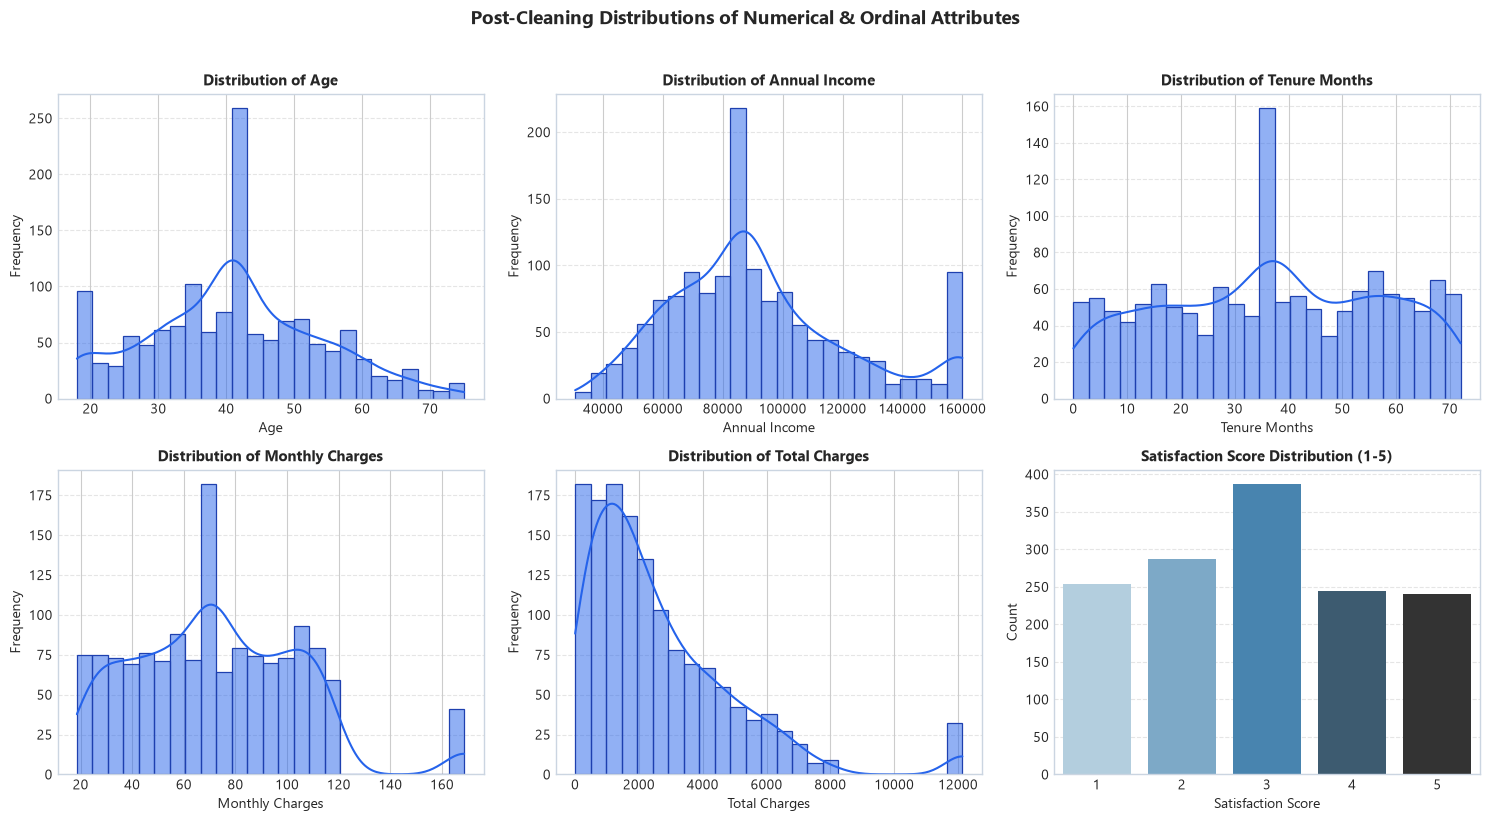

In [22]:
# Plot final distributions of cleaned numerical & ordinal features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2563EB", bins=25, edgecolor="#1E40AF")
    axes[i].set_title(f"Distribution of {col.replace('_', ' ').title()}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

sns.countplot(x=df['satisfaction_score'], ax=axes[5], palette="Blues_d", hue=df['satisfaction_score'], legend=False)
axes[5].set_title("Satisfaction Score Distribution (1-5)", fontsize=11, fontweight="bold")
axes[5].set_xlabel("Satisfaction Score", fontsize=10)
axes[5].set_ylabel("Count", fontsize=10)
axes[5].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Post-Cleaning Distributions of Numerical & Ordinal Attributes", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Step 9: Export the Cleaned Dataset to CSV
We persist both the clean analysis-ready dataset and the ML-ready encoded dataset to disk.


In [23]:
cleaned_path = '../data/cleaned/customer_churn_cleaned.csv'
encoded_path = '../data/cleaned/customer_churn_encoded.csv'

df.to_csv(cleaned_path, index=False)
df_encoded.to_csv(encoded_path, index=False)

print(f"Saved Cleaned Dataset: {cleaned_path} ({os.path.getsize(cleaned_path):,} bytes)")
print(f"Saved Encoded Dataset: {encoded_path} ({os.path.getsize(encoded_path):,} bytes)")

Saved Cleaned Dataset: ../data/cleaned/customer_churn_cleaned.csv (184,948 bytes)
Saved Encoded Dataset: ../data/cleaned/customer_churn_encoded.csv (255,583 bytes)


## Step 10: Before-and-After Comparison Table of Data Quality Metrics
The table below encapsulates the complete transformation across all quality dimensions.


In [24]:
comparison_df = pd.read_csv('../outputs/tables/before_after_metrics.csv')
display(comparison_df)

,Metric,Before Cleaning (Raw),After Cleaning,Delta / Impact
0,Total Rows,"1,550","1,413",-137 rows removed
1,Total Columns,16,16,Standardized to clean snake_case
2,Total Missing Values,"1,522 cells (6.1%)",0 cells (0.0%),100% imputed / resolved
3,Exact Duplicate Rows,35,0,35 duplicates purged
4,Duplicate Customer IDs,74,0,Ensured 1-to-1 customer granularity
5,Column Naming Standard,"Messy (' Customer_ID ', 'Annual Income ($)')",Normalized snake_case,Programmatic consistency
6,Annual Income Data Type,"object (strings with '$', ',')",float64 (numeric),Enables mathematical aggregation
7,Total Charges Data Type,object (strings with ' ' blanks),float64 (numeric),Reconciled with tenure * monthly
8,Join Date Data Type,object (mixed date string formats),datetime64[ns],Enables temporal time-series queries
9,Negative Age / Incomes,Present (entry typos),0 (purged / imputed),Domain logic enforced


## Conclusion & Next Steps
The raw, messy customer churn dataset has been successfully transformed into a rigorous, production-grade format:
- **Zero Missing Values**: Imputed via statistical medians, domain formulas, and documented categories.
- **Zero Duplicates**: Exact duplicates and primary key collisions purged.
- **Standardized Schema**: Normalized to clean `snake_case` with verified data types.
- **Tamed Outliers**: Winsorized extreme billing glitches and typos using IQR clipping.
- **Dual Outputs**: Provided both human-readable analytical CSV and encoded numerical ML-ready CSV.
